## **Project Title: Customer Churn Prediction & Risk Segmentation Dashboard**
### Problem statement
- Subscription-based businesses lose significant revenue every year due to customer churn (customers who cancel or stop using a service).
- Predicting which customers are likely to churn before they actually leave allows the business to act proactively: offer discounts, improve support, or tailor communication.

### Objective:
- Build an end-to-end customer churn prediction system using a telecom dataset by performing EDA, feature engineering, model training and evaluation, and advanced churn-risk segmentation with interactive visualizations.

### Dataset overview
- The dataset used is the Telco Customer Churn Dataset available on Kaggle. It contains customer-level information from a telecom company and is widely used for customer churn prediction problems in machine learning and business analytics.

- Kaggle link : https://www.kaggle.com/datasets/blastchar/telco-customer-churn

- Dataset size and structure:
    - Total Records: 7,043 customers
    - Total Columns: 21 features
    - Target Variable: Churn

### **TASK 1 - Data Loading & Exploratory Analysis**

In [3]:
import pandas as pd                                         # Pandas library used to load, inspect, clean, transform, and analyze tabular data
import numpy as np                                          # Numpy library used for numerical operations
import matplotlib.pyplot as plt                             # Matplotlib library used for data visualization
import seaborn as sns                                       # Seaborn library used for statistical data visualization

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')    # Read the data from the csv file

In [4]:
print("Dataset Shape:", df.shape)   # Display the shape of the dataset (number of rows and columns)
print("")
print("Column Types:\n",df.dtypes)  # Display the data types of each column in the dataset.

Dataset Shape: (7043, 21)

Column Types:
 customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [5]:
df.head(10)     # Display the first 10 rows of the dataset

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [6]:
print(df.columns)                                       # Display the column names of the dataset
target = 'Churn'                                        # Define the target column
print("\nTarget Column\n", df[target].value_counts())   # Display the count of each unique values in the target column

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

Target Column
 Churn
No     5174
Yes    1869
Name: count, dtype: int64


- The data reveals that **most customers did not churn** and only **few** of the customers **churned**.
- This indicates **class imbalance**

In [7]:
print(df.isnull().sum())                # Check for missing values in each column of the dataset and display the count of missing values for each column

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [8]:
for col in df.columns:
    print(col,(df[col] == " ").sum())  # Check for empty string values in each column since blank values(" ") are not treated as NULL values by pandas.

customerID 0
gender 0
SeniorCitizen 0
Partner 0
Dependents 0
tenure 0
PhoneService 0
MultipleLines 0
InternetService 0
OnlineSecurity 0
OnlineBackup 0
DeviceProtection 0
TechSupport 0
StreamingTV 0
StreamingMovies 0
Contract 0
PaperlessBilling 0
PaymentMethod 0
MonthlyCharges 0
TotalCharges 11
Churn 0


- This indicates there are 11 missing values in the column 'TotalCharges'

In [9]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')  # Handling the blanck spaces where they are converted to NaN and the valid numbers remain unchanged.
print(df.isnull().sum())                                                 # Verify that the blank spaces are converted to NULL values

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [10]:
(11 / 7043) * 100   # Calculate the percentage of missing values

0.1561834445548772

- Since the total percentage of missing values in the dataset is substancially small, we can consider droppping the rows instead of imputing.
- Imputation may introduce artificial values.

In [11]:
df.dropna(inplace=True)     # Drop the rows with missing values
print(df.isnull().sum())    # Verify that there are no missing values in the dataset
print(df.shape)             # Display the shape of the dataset after dropping the rows with missing values

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
(7032, 21)


In [12]:
print(df.describe())   # Display the statistical summary of the dataset for numerical columns

       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7032.000000  7032.000000     7032.000000   7032.000000
mean        0.162400    32.421786       64.798208   2283.300441
std         0.368844    24.545260       30.085974   2266.771362
min         0.000000     1.000000       18.250000     18.800000
25%         0.000000     9.000000       35.587500    401.450000
50%         0.000000    29.000000       70.350000   1397.475000
75%         0.000000    55.000000       89.862500   3794.737500
max         1.000000    72.000000      118.750000   8684.800000


- **The statistical summary is derived where the 50% row is essentially the median of the dataset**

In [13]:
df["Churn"] = df["Churn"].map({                # Convert the target column "Churn" to binary values where "No" is 0 and "Yes" is 1
    "No": 0,
    "Yes": 1
})

corr_df = df.select_dtypes(include=np.number)  # Select only the numerical columns from the dataset for correlation analysis

print(corr_df)                                 # Display the dataframe containing only the numerical columns

      SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn
0                 0       1           29.85         29.85      0
1                 0      34           56.95       1889.50      0
2                 0       2           53.85        108.15      1
3                 0      45           42.30       1840.75      0
4                 0       2           70.70        151.65      1
...             ...     ...             ...           ...    ...
7038              0      24           84.80       1990.50      0
7039              0      72          103.20       7362.90      0
7040              0      11           29.60        346.45      0
7041              1       4           74.40        306.60      1
7042              0      66          105.65       6844.50      0

[7032 rows x 5 columns]


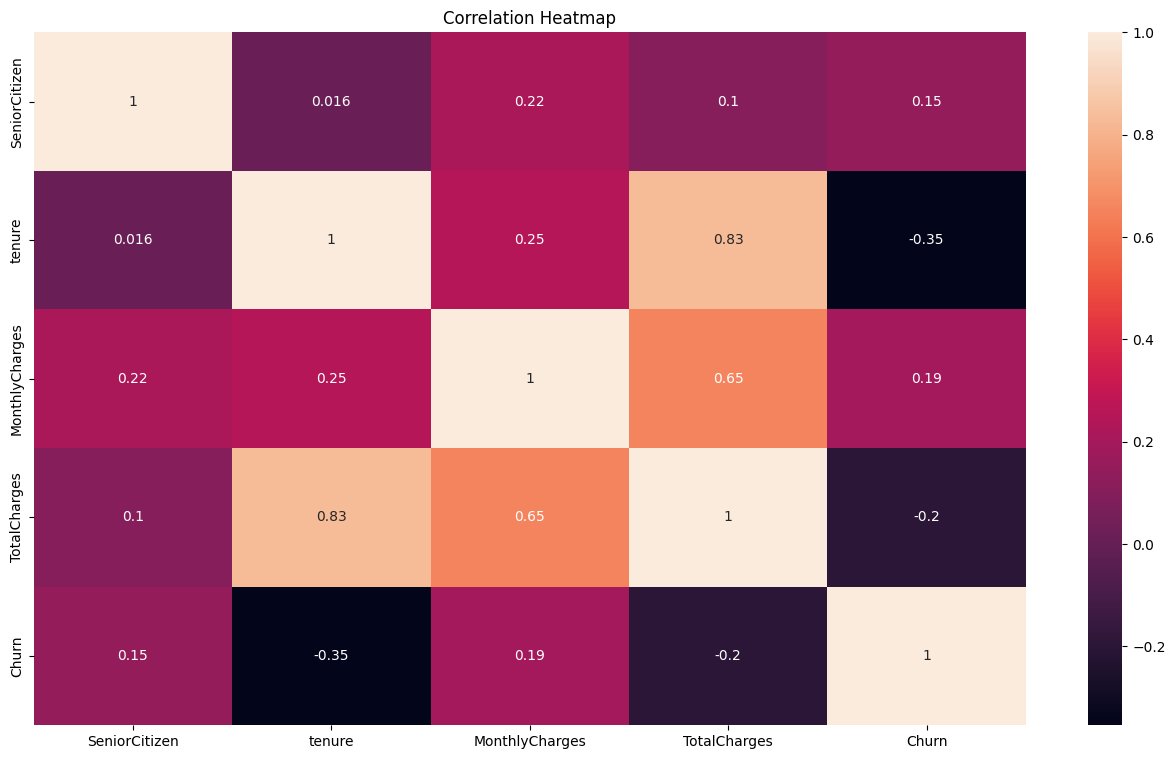

In [14]:
plt.figure(figsize=(16, 9))   # Set the figure size for the heatmap

sns.heatmap(
    corr_df.corr(),
    annot=True
)
plt.title("Correlation Heatmap")
plt.show()

- From the correlation matrix, it is observed that:

    - **'tenure'** shows a negative correlation with churn, indicating that **long-term customers are less likely to leave the service.**

    - **'TotalCharges'** also shows a negative correlation with churn because **'TotalCharges' indirectly indicates long customer tenure** which means less churn thus this relationship exists. It **does not directly prevent churn.**

    - **'MonthlyCharges** has a positive correlation with churn indicating customers with **higher monthly bills are more likely to churn.**

    - **'SeniorCitizen'** has also a positive relationship with churn but with only a small value, it **indicates higher churn** chances but it is not a very confident correlation. It would result in a much stronger prediction if combined with other features.

### **TASK 2 - Data Preprocessing & Feature Engineering**

In [15]:
print(df.shape)                 # Verify the shape of the dataset after Task 1

print("\nMissing Values:")
print(df.isnull().sum().sum())  # Verify that there are no missing values

print("\nData Types:")
print(df.dtypes)                # Verify the data types of each column

(7032, 21)

Missing Values:
0

Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


- 'TotalCharges' was already converted to numeric data type in the previous steps.

In [16]:
cat_cols = df.select_dtypes(include="object").columns   # Identify and display the categorical columns in the dataset
print(cat_cols)

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='str')


C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_21232\1831975622.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns   # Identify and display the categorical columns in the dataset


- Since 'customerID' has no behavioural information, it won't help generalize patterns.
- Keeping 'customerID' may lead the model to overfitting. So the best choice it to drop this column.

In [17]:
df.drop('customerID', axis=1, inplace=True)   # Drop the "customerID" column since it is not useful.

- **One-Hot Encoding**: One-Hot Encoding converts each category of a categorical variable into a new binary column. Each column represents a unique category where a value of 1 indicates the presence of that category and 0 indicates its absence.

- **Label Encoding**: Label Encoding assigns each category of a categorical variable a unique integer value. This converts the categorical column into a single numerical feature.

Label Encoding is best suited for ordinal data where categories have a natural order while our dataset includes nominal categorical data and the number of unique of values is relatively small.
Therefore, **One-Hot Encoding was selected** because the dataset contains mostly nominal categorical variables with no natural ordering. It is also the most suitable encoding strategy for maintaining compatibility and performance across Logistic Regression, Random Forest, and Gradient Boosting models.

In [18]:
df_encoded = pd.get_dummies(df,drop_first=True)     # Apply One-Hot Encoding

print(df.shape)                                     # Display the shape of the original dataset
print(df_encoded.shape)                             # Display the shape of the dataset after encoding

(7032, 20)
(7032, 31)


- New Features:

    - **ChargesPerMonth = TotalCharges / tenure**

    - **SeniorWithNoSupport = (SeniorCitizen == 1) & (TechSupport == "No")**

In [19]:
df_encoded["ChargesPerMonth"] = (       # Creating the new feature 'ChargesPerMonth'
df_encoded["TotalCharges"] /
    (df_encoded["tenure"])
)

In [20]:
df_encoded["SeniorWithNoSupport"] = np.where((df_encoded["SeniorCitizen"] == 1) & (df["TechSupport"] == "No"), 1, 0)    # Creating the new feature 'SeniorWithNoSupport'

In [21]:
print(df_encoded[["ChargesPerMonth", "SeniorWithNoSupport"]].head(10))   # Display the first 10 rows of the new features created

   ChargesPerMonth  SeniorWithNoSupport
0        29.850000                    0
1        55.573529                    0
2        54.075000                    0
3        40.905556                    0
4        75.825000                    0
5       102.562500                    0
6        88.609091                    0
7        30.190000                    0
8       108.787500                    0
9        56.257258                    0


In [22]:
from sklearn.preprocessing import StandardScaler    # Import the library for deature scaling
scaler = StandardScaler()                           # Initialize the StandardScaler for feature scaling

In [23]:
x = df_encoded.drop("Churn",axis=1)     # Define the features into variable 'x'

y = df_encoded["Churn"]                 # Define the target variable into 'y' which is the "Churn" column

In [24]:
x_scaled = scaler.fit_transform(x)        # Apply feature scaling

In [25]:
from sklearn.model_selection import train_test_split        # Importing the train_test_split function from scikit-learn library to split the dataset into training and testing sets

x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42, stratify=y)   # Split the dataset where 80% of the data is used for training and 20% is used for testing

In [26]:
print("Training Shape:", x_train.shape)     # Verify split shapes
print("Testing Shape:", x_test.shape)

Training Shape: (5625, 32)
Testing Shape: (1407, 32)


In [27]:
print("Original Distribution:")
print(y.value_counts(normalize=True))                       

print("\nTraining Distribution:")
print(pd.Series(y_train).value_counts(normalize=True))      # Compare the distribution of classes with the original distribution

print("\nTesting Distribution:")
print(pd.Series(y_test).value_counts(normalize=True))

Original Distribution:
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

Training Distribution:
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

Testing Distribution:
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


- The class distribution is similar across all datasets. Therefore the stratification was successfull

### **TASK 3 - Model Training and Comparison**

In [28]:
from sklearn.linear_model import LogisticRegression         # Import all the necessary libraries for model training and evaluation
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay

- Logistic Regression, Random Forest Classifier, and Gradient Boosting Classifier were selected because they are reliable and widely used models for binary classification problems like customer churn prediction. These models also allow comparison between simple linear learning and more advanced ensemble-based approaches. Other complex models such as deep learning were not used because the dataset is relatively small and structured, making simpler models more efficient, interpretable, and suitable for this problem.

In [29]:
LR_model = LogisticRegression()

RFC_model = RandomForestClassifier()

GB_model = GradientBoostingClassifier()         # Initialize all the three models

In [30]:
LR_model.fit(x_train, y_train)    # Train the Logistic Regression model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [31]:
RFC_model.fit(x_train, y_train)   # Train the Random Forest Classifier model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [32]:
GB_model.fit(x_train, y_train)    # Train the Gradient Boosting Classifier model

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

#### **During this 'fit' process:**
- The models study feature patterns
- learns relationships between inputs and churn labels
- builds mathematical decision rules

### Generate Predictions for each models: 

In [33]:
LR_pred = LR_model.predict(x_test)

In [34]:
RFC_pred = RFC_model.predict(x_test)

In [35]:
GB_pred = GB_model.predict(x_test)

'.predict()' returns '0' or '1' values for each row, where '0' represents 'No Churn' and '1' represents 'Churn'

### Now we need to generate Prediction Probabilities
    'ROC-AUC' and 'ROC Curve' require probabilities instead of class labels.

In [36]:
LR_prob = LR_model.predict_proba(x_test)[:, 1]

In [37]:
RFC_prob = RFC_model.predict_proba(x_test)[:, 1]

In [38]:
GB_prob = GB_model.predict_proba(x_test)[:, 1]

**Since only the Churn probabilities are required, '[:, 1]' helps to select the probabilities corresponding to the positive class (Churn = 1) from the output of predict_proba() method.**

### Metric Evaluation:

**ACCURACY: (TN + TP) / (TN + FN + TP + FP)**

- Accuracy measures the overall correctness of the predictions.

**PRECISION: (TP) / (FP + TP)**
- It measures how many of the positive predictions made by the model are actually correct.
- Precision helps ensure that when the model predicts a positive outcome, it’s likely to be correct.

**RECALL: (TP / (TP + FN))**
- It measures how many of the actual positive cases were correctly identified by the model.

**F1-SCORE: 2 * [(PRECISION * RECALL) / (PRECISION + RECALL)]**
- It is useful when we need a balance between precision and recall as it combines both into a single number.
- More the F1 score better will be performance.


**ROC CURVE:**
- It is a graphical representation that shows how good the model is at distinguishing between classes.
- The ROC curve plots:
    - True Positive Rate (Recall) on Y-axis - (TPR = TP / (TP + FN))
    - False Positive Rate on X-axis - (FPR = FP / (FP + TN))

**ROC-AUC**:
- Measures the total Area Under the ROC Curve
- ROC-AUC tells us how well the model separates positive and negative classes

- **ROC and ROC-AUC are related, but they are not the same thing.**

- ROC = Graph

- ROC-AUC = the single number summarizing that graph

In [39]:
def evaluate(y_true, y_pred, y_prob):               # Defined a function to evaluate the model performance using various metrics
    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(y_true, y_pred)

    recall = recall_score(y_true, y_pred)

    f1 = f1_score(y_true, y_pred)

    roc_auc = roc_auc_score(y_true, y_prob)

    print("Accuracy: ",accuracy)                    # Display the evaluation metrics
    print("Precision: ",precision)
    print("Recall: ",recall)
    print("F1 Score: ",f1)
    print("ROC AUC: ",roc_auc)

#### After defining and initializing all metric functions, we will now evaluate all models:

In [40]:
print("\nLOGISTIC REGRESSION\n")

evaluate(y_test,LR_pred,LR_prob)            # Evaluate the Logistic Regression model


LOGISTIC REGRESSION

Accuracy:  0.8052594171997157
Precision:  0.6506024096385542
Recall:  0.5775401069518716
F1 Score:  0.6118980169971672
ROC AUC:  0.8357090350000776


In [41]:
print("\nRANDOM FOREST CLASSIFIER\n")

evaluate(y_test,RFC_pred,RFC_prob)          # Evaluate the Random Forest Classifier model


RANDOM FOREST CLASSIFIER

Accuracy:  0.7903340440653873
Precision:  0.6321070234113713
Recall:  0.5053475935828877
F1 Score:  0.5616641901931649
ROC AUC:  0.8148725740406169


In [42]:
print("GRADIENT BOOSTING CLASSIFIER\n") 

evaluate(y_test,GB_pred,GB_prob)            # Evaluate the Gradient Boosting Classifier model

GRADIENT BOOSTING CLASSIFIER

Accuracy:  0.7938877043354655
Precision:  0.635483870967742
Recall:  0.5267379679144385
F1 Score:  0.5760233918128655
ROC AUC:  0.8407201391513219


#### KEY OBSERVATIONS:


- All three models performed reasonably well, with **Accuracy close to 79–80%** and **minimum ROC-AUC score of 0.81**.

- This indicates that the dataset contains meaningful predictive patterns for customer churn, and the models are capable of distinguishing churn vs non-churn customers.



#### GENERATING MATRICES FOR ALL 3 MODELS:

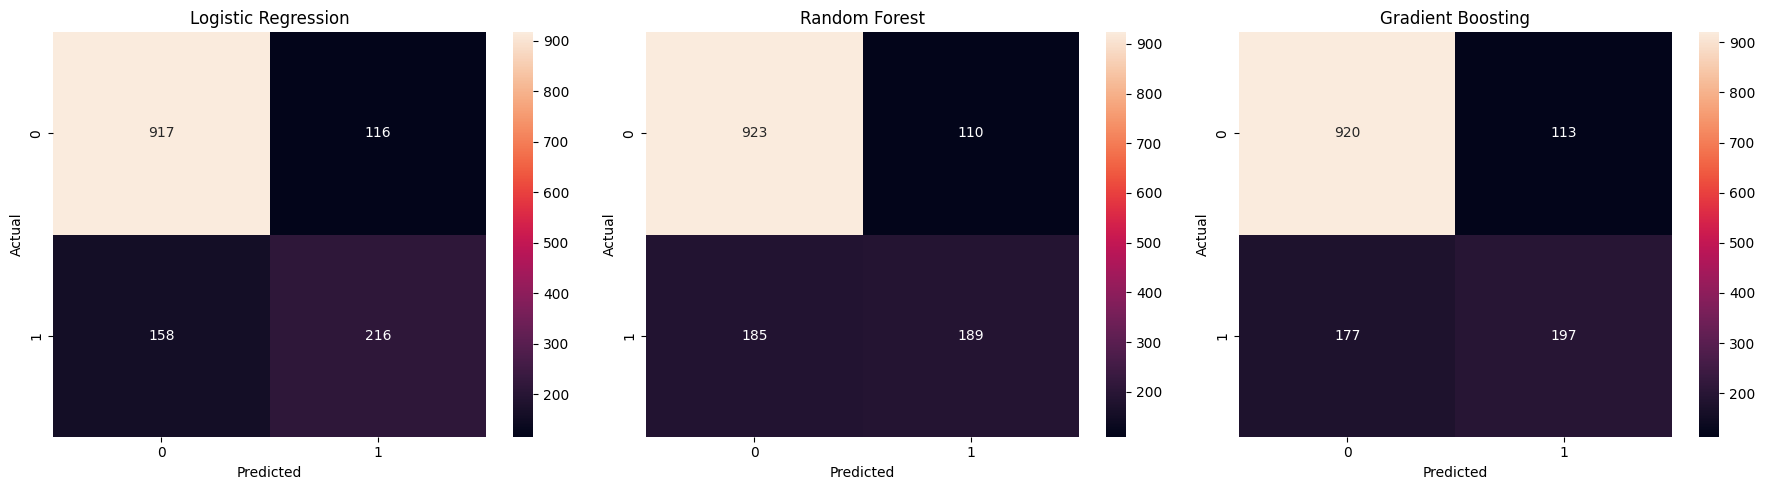

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

predictions = {
    "Logistic Regression": LR_pred,
    "Random Forest": RFC_pred,
    "Gradient Boosting": GB_pred
}

for ax, title in zip(axes, predictions):

    sns.heatmap(
        confusion_matrix(y_test, predictions[title]),
        annot=True,
        fmt="d",
        ax=ax
    )

    ax.set(
        title=title,
        xlabel="Predicted",
        ylabel="Actual"
    )

plt.tight_layout()
plt.show()

- The True Negatives (top-left section) are very high across all models:
    - This indicates that the models are reliable in recognizing customers who are likely to stay.

- The True Positives (bottmo-right section) are also significant because it helps correctly identifying churn customers enabling the company to intervene before customer loss.

- The False Negative (bottom-left section) represents customers who actually churned but were predicted as non-churn.
    - This is the most costly error type as from a business standpoint, these customers leave without receiving any retention effort.

- The False Positives (top-right section) represents the customers who were predicted to churn but actually stayed.

#### PLOT ROC CURVES

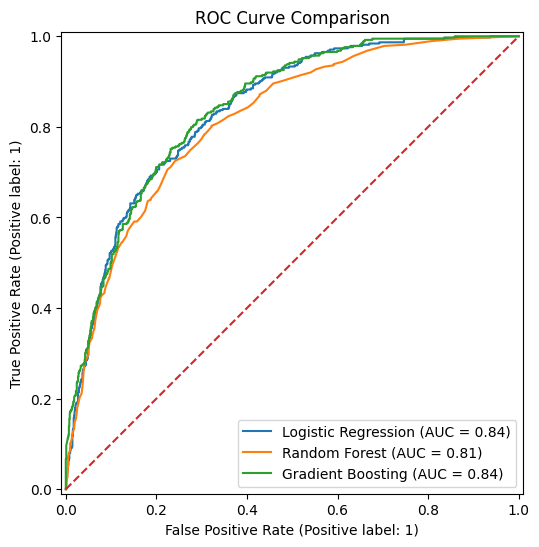

In [44]:
fig, ax = plt.subplots(figsize=(8,6))

# Logistic Regression
RocCurveDisplay.from_predictions(
    y_test,
    LR_prob,
    name="Logistic Regression",
    ax=ax
)

# Random Forest
RocCurveDisplay.from_predictions(
    y_test,
    RFC_prob,
    name="Random Forest",
    ax=ax
)

# Gradient Boosting
RocCurveDisplay.from_predictions(
    y_test,
    GB_prob,
    name="Gradient Boosting",
    ax=ax
)

# Random baseline
ax.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

ax.set_title("ROC Curve Comparison")

plt.show()

- From the chart above, it is evident that all three models demonstrate strong predictive capability, as each model curve remain above the baseline.

- Out of the three, Logistic Regression and Gradient Boosting Classifier achieved the strongest performance, with ROC-AUC values of near 0.84, indicating superior class separation capability.

#### Optimizing best model using Hyperparameter Tuning
- To Identify the best model, we need to understand the business requirements, which directly responds to the model performace.

**In our case, we need to know how effectively can the company identify customers likely to leave before they actually churn, because of this specific requirement, Recall and ROC-AUC becomes especially important.**

- **Highest Accuracy: ~80.5%**
- **Highest Recall: ~57.8%**
- **Highest F1-Score: ~61.2%**
- **Strong ROC-AUC: ~0.84**

##### **LOGISTIC REGRESSION emerged as the strongest overall model.**

#### Now we optimize our best performing model using RandomizedSearchCV:


In [67]:
from sklearn.model_selection import RandomizedSearchCV      # Importing the RandomizedSearchCV function to perform hyperparameter tuning

In [68]:
param_dist = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],                # Define the distribution of hyperparameters for Logistic Regression model to be used in RandomizedSearchCV
    "solver": ["liblinear", "lbfgs"],                   # "liblinear" and "lbfgs" are optimization algorithms commonly used as solvers for linear models like Logistic Regression.
}                                                                         

log_cv = RandomizedSearchCV(
    estimator=LR_model,
    param_distributions=param_dist,
    cv=10,
    scoring='f1'
)                                                       # Initialize the RandomizedSearchCV with the Logistic Regression model, the defined parameter distributions, and 10-fold cross-validation

log_cv.fit(x_train,y_train)

print("Tuned Logistic Regression Parameters:", log_cv.best_params_)         # Display the best parameters found by RandomizedSearchCV for Logistic Regression model

Tuned Logistic Regression Parameters: {'solver': 'liblinear', 'C': 0.001}


##### This indicates that among all the provided parameters, **Logistic Regression performed best with C = 10 and 'L2' (Ridge) Regularization.**
- This means that the model performed better with weaker regularization and higher flexibility.



#### Now we need to extract the best tuned model and then evauate it

In [69]:
best_model = log_cv.best_estimator_                 # Get the best model from RandomizedSearchCV


best_pred = best_model.predict(x_test)              # Get the class predictions


best_prob = best_model.predict_proba(x_test)[:, 1]  # Get the class prediction probabilities

In [70]:
evaluate(y_test, best_pred, best_prob)             # Evaluate the best Logistic Regression model after hyperparameter tuning

Accuracy:  0.7917555081734187
Precision:  0.5939675174013921
Recall:  0.6844919786096256
F1 Score:  0.6360248447204969
ROC AUC:  0.8311017181668056


From the optimized model evaluation results, **there is a clear and major shift in Recall from ~57.7% to ~68.4%.**
- This indicates that the model now identifies more actual churn customers.
- Fewer at-risk customers are being missed.

**Trade-Off** happened:
- In order to gain higher Recall, **Precision decreased from ~65% to ~59%** and **Accuracy slightly decreased from ~80% to ~79%**, which means, that the model now flag more customers at churn risk but some of them will be false alarms.

The **F1-Score slightly improved** which means the balance between Precision and Recall improved overall.
- SInce the churn dataset is imbalanced, F1-Score is more reliable and meaningful than Accuracy

The **ROC-AUC** value very slightly decreased, indicating that the **model can still distinguish between classes confidently.**

### **TASK 4 - Customer Risk Segmentation**

We will now use the churn probabilities generated bythe tuned Logistic Regression model and divide customers into risk groups.

#### Generate churn probabilities for the entire dataset:


In [72]:
all_prob = best_model.predict_proba(x_scaled)[:,1]      # Get the churn probabilities for the entire dataset using the tuned Logistic Regression model

#### Now we need to create a dataframe that will be used for Risk Segmentation

In [73]:
risk_df = df.copy()     # Creating a copy of the original dataframe that preserves customer information and avoids modifying the original dataframe

In [74]:
risk_df["Churn_Probability"] = all_prob     # Add the churn probabilities as a new column in the risk_df dataframe

- Now every customer has actual features and predicted churn probability

#### Customers are to be divided into 3 segments:
- **HIGH RISK    : Probability ≥ 0.70**

- **MEDIUM RISK  : Probability between 0.40 and 0.69**

- **LOW RISK     : Probability < 0.40**

In [75]:
def segment(prob):              # Defining a fucntion that takes probability as input to segment customers based their churn probabilities
    if prob >= 0.70:
        return "High Risk"
    
    elif prob >= 0.40:
        return "Medium Risk"
    
    else:
        return "Low Risk"       # Returns appropriate risk segment

In [76]:
risk_df["risk_tier"] = risk_df["Churn_Probability"].apply(segment)

- This operation creates a new feature 'risk_tier', which holds the customer segmentation labels

In [77]:
risk_df[["Churn_Probability","risk_tier","gender","Contract"]].head()     # Verify the risk segmentation

,Churn_Probability,risk_tier,gender,Contract
0,0.529587,Medium Risk,Female,Month-to-month
1,0.239730,Low Risk,Male,One year
2,0.415469,Medium Risk,Male,Month-to-month
3,0.189628,Low Risk,Male,One year
4,0.689808,Medium Risk,Female,Month-to-month


- The Risk Segmentation for each customer was successful

#### Now we need to identify the count of customers in each tier:

In [78]:
risk_counts = risk_df["risk_tier"].value_counts()     # Count the number of customers in each risk tier
print("Risk Tier Distribution:")
print(risk_counts)

Risk Tier Distribution:
risk_tier
Low Risk       4048
Medium Risk    2651
High Risk       333
Name: count, dtype: int64


#### For each Tier we need to compute average MonthlyCharges, average tenure, and Contract type distribution

In [79]:
tier_dist = risk_df.groupby("risk_tier")[["MonthlyCharges","tenure"]].mean()     # Calculate the average monthly charges for each risk tier and the average tenure for each risk tier


contract_dist = pd.crosstab(risk_df["risk_tier"],risk_df["Contract"])            # Calculate the distribution of contract types within each risk tier


tier_dist = pd.concat([tier_dist,contract_dist],axis=1)                          # Concatenate tier_dist and contract_dist into a single dataframe


print(tier_dist)

             MonthlyCharges     tenure  Month-to-month  One year  Two year
risk_tier                                                                 
High Risk         85.112913   6.147147             333         0         0
Low Risk          56.612846  43.297431            1061      1314      1673
Medium Risk       74.745228  19.115428            2481       158        12


- Since 'MonthlyCharges' and 'tenure' are numerical data types and 'Contract' is a string data type, they cannot be calculated together
- So for Contract type distribution, it was separatelt calculated using 'crosstab' and then concatenated into the final structure

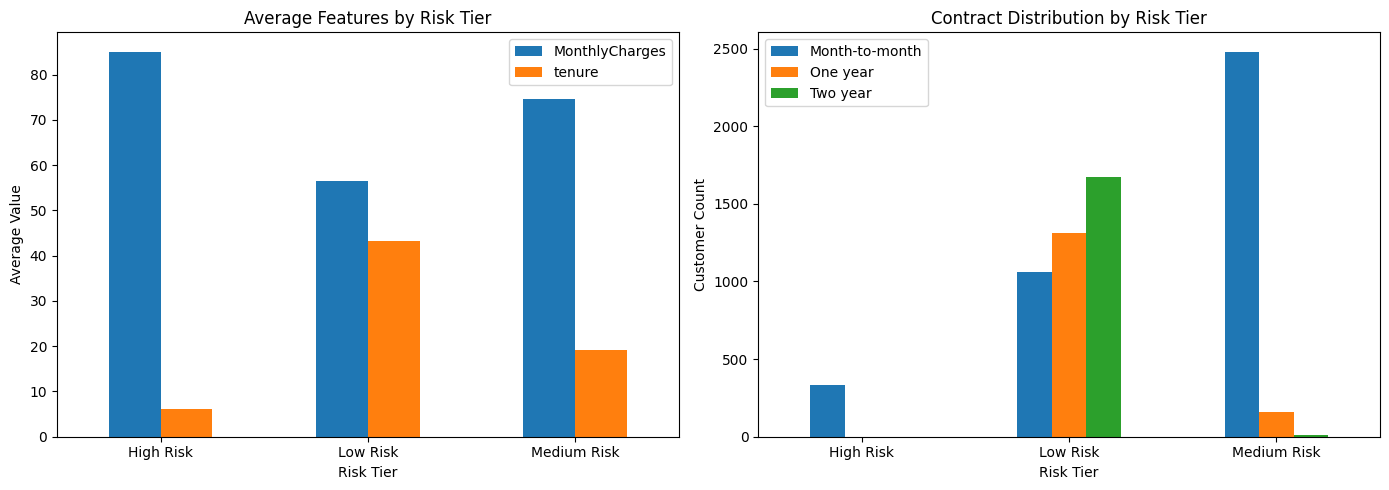

In [ ]:
fig, axes = plt.subplots(           # Using subplots to create the two bar charts side by side for better comparison

    1,
    2,

    figsize=(14,5)
)

tier_dist[
    [
        "MonthlyCharges",
        "tenure"
    ]
].plot(kind="bar",ax=axes[0])


axes[0].set_title("Average Features by Risk Tier")

axes[0].set_xlabel("Risk Tier")

axes[0].set_ylabel("Average Value")

axes[0].tick_params(axis="x",rotation=0)

tier_dist[
    [
        "Month-to-month",
        "One year",
        "Two year"
    ]
].plot(kind="bar",ax=axes[1])


axes[1].set_title("Contract Distribution by Risk Tier")

axes[1].set_xlabel("Risk Tier")

axes[1].set_ylabel("Customer Count")

axes[1].tick_params(axis="x",rotation=0)

plt.tight_layout()

plt.show()

- Since contract distribution is categorical count data, it was treated separately rather than mixed into the same grouped average feature chart.

- Side-by-side grouped bar charts were created to compare customer behavior across churn risk tiers. The visualizations highlight differences in average customer metrics and contract type distributions, helping identify patterns associated with high churn probability.

#### Key Observation:

- Customers who pay the **highest charges are significantly more likely to leave**.

- **The High Risk** customers have a shorter tenure and all of them use Month-to-Month contract, which means **customers without long-term commitment are significantly more likely to leave**

- **Low-Risk** customers are heavily concentrated **in One year and Two year contracts** which indicates that contract commitments heavily incluence customer retention behaviour.

### **TASK 5 - Visualizations**

#### Chart - 1 (Feature Importance):

In [81]:
features = pd.DataFrame({
    "Feature": x.columns,
    "Importance":RFC_model.feature_importances_     # Using the feature_importances_ attribute of the Random Forest Classifier model to get the importance of each feature
})

top_features = features.sort_values(
    by="Importance",
    ascending=False
).head(10)                                          # Sort the features based on their importance and select the top 10 features

- The feature importance chart for Random Forest Classifier model is required, so the top features were selected and stored in 'top_features'

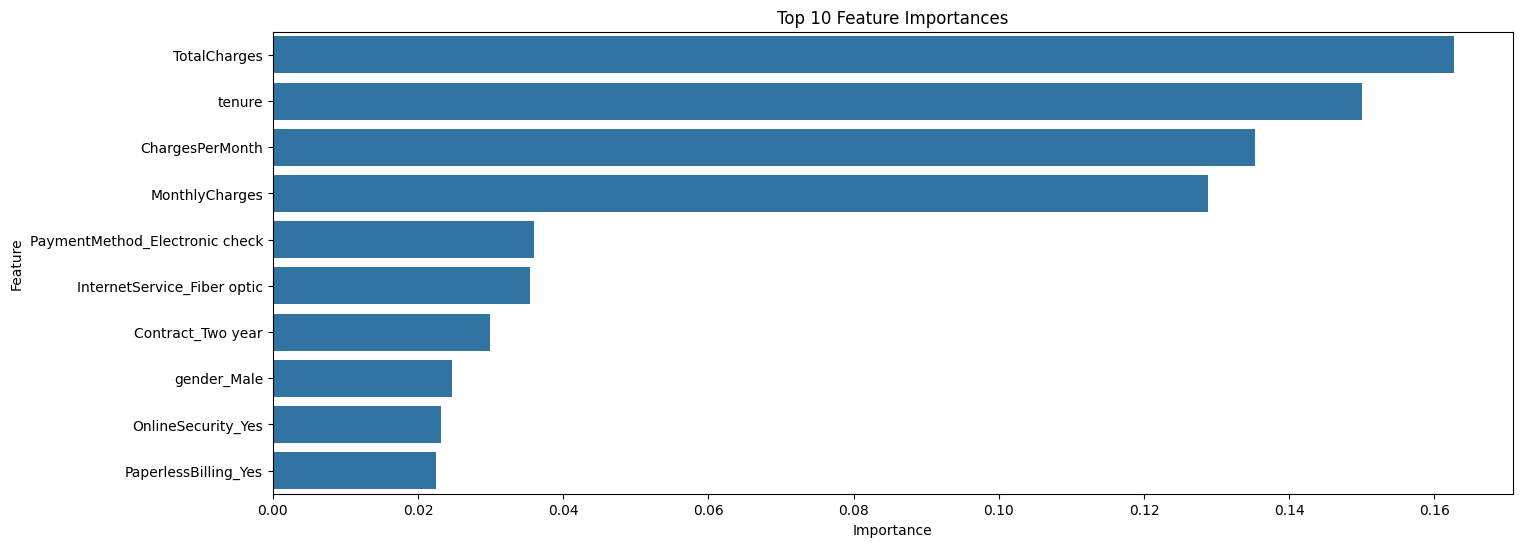

In [82]:
plt.figure(figsize=(16,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

- This chart clearly shows that features, **'TotalCharges', 'tenure', 'ChargesPerMonth' and 'MonthlyCharges'** contributed most to predict churn probabilities and heavily influence the outcome of the model

#### Chart - 2 (Churn rate by Contract Type):

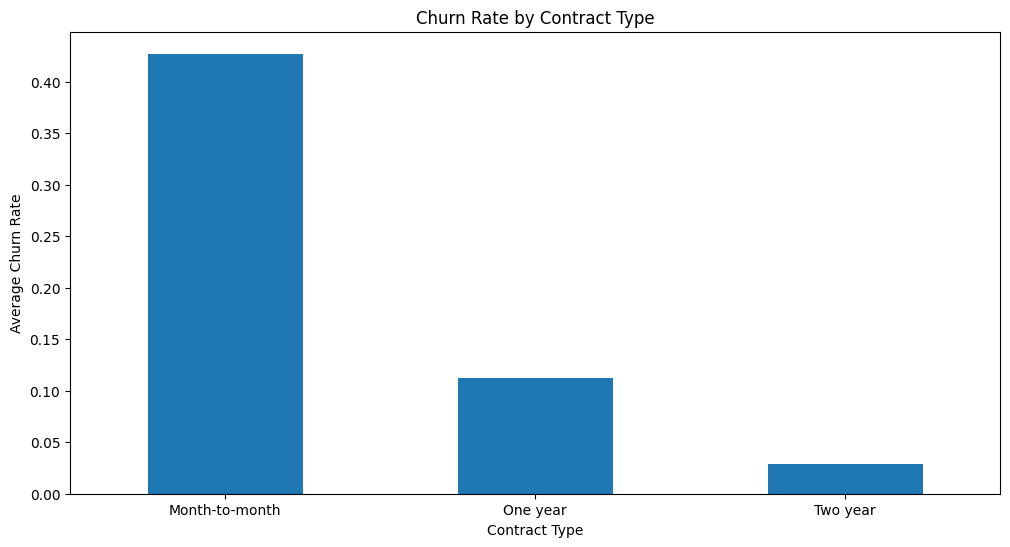

In [83]:
churn_rate = df.groupby("Contract")["Churn"].mean()     # Calculate churn rate for each contract type and calculate the mean of churn for each contract type

churn_rate.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Churn Rate by Contract Type")

plt.ylabel("Average Churn Rate")

plt.xlabel("Contract Type")

plt.xticks(rotation=0)

plt.show()

- Customers who are using Month-to-month contract type are significantly more likely to churn.

- While long term customers are reduce churn chances significantly.

#### Chart - 3 (Distribution of Tenure):

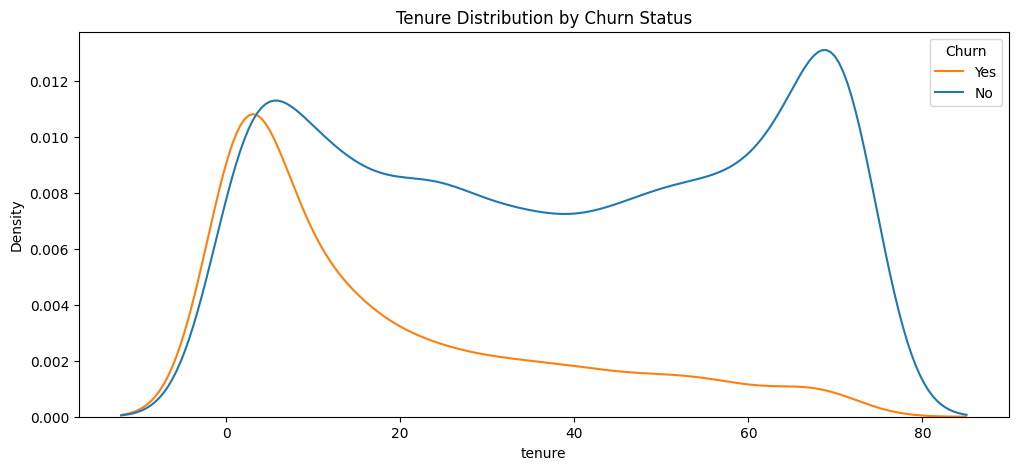

In [84]:
plt.figure(figsize=(12,5))
sns.kdeplot(
    data=df,
    x="tenure",
    hue="Churn"
)

plt.title("Tenure Distribution by Churn Status")

plt.legend(title="Churn", labels=["Yes", "No"])

plt.show()

- The tenure distribution clearly indicated that churned customers were heavily concentrated in the earlier months of their customer lifecycle.

- Customers with low tenure exhibit significantly higher churn probability, while long-tenure customers are substantially more stable and less likely to leave.

#### Chart - 4 (Customer Distribution across Risk Tiers):

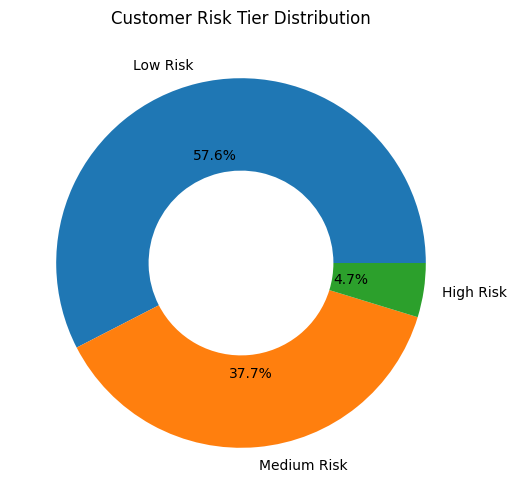

In [101]:
risk_counts = risk_df["risk_tier"].value_counts()       # Count the number of customers in each risk tier

plt.figure(figsize=(13,6))

plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct="%.1f%%",
    wedgeprops={"width": 0.5}
)

plt.title("Customer Risk Tier Distribution")
plt.show()

- The customer risk tier distribution indicates that the majority of customers fall within the Low-Risk category, while only a relatively small proportion are classified as High Risk.

#### Chart - 4 (Interactive scatter plot):

In [105]:
import plotly.express as px

fig = px.scatter(
    df,
    x="tenure",
    y="MonthlyCharges",
    color="Churn",
    title="MonthlyCharges vs Tenure by Churn"
)
fig.show()


- The scatterplot suggests that customers with low tenure, and high monthly charges show noticeably higher churn concentration.

- As tenure increases, churn observations become less concentrated, which suggests that customer satisfaction increases over time.

### **TASK 6 - Insights & Business Recommendations**

Among all the evaluated models, Logistic Regression achieved the best overall performance and was selected as the final model for churn prediction.
Logistic Regression performed significantly better across key metric such as Recall, F1-Score and ROC-AUC.

Based on the observations from correlation analysis, and overall customer behaviour, the three strongest factors that influence customer churn are:
- Contract Type
    - Contract Type emerged as the most influential churn related field. Customers using Month-to-month contract showed the highest churn rate out of the other contract types. Long term contracts exhibit loyal customers who increase customer retention as they create service continuity

- Tenure
    - Tenure showed a strong negative relationship with churn. Customers with high tenure showed much higher retention rates while customers with shorter tenure were more likely to leave the service.

- MonthlyCharges
    - Customers with high monthly charges were seen to depict greater churn probability. 

The High Risk customers have predominant Month-to-month contracts, shorter tenures, and high monthly charges. These were the three most common properties found for the high risk customers.


According to the highest churn determining factors, customers with low tenure and short-term contract types showed to highest churn rate.

The best business recommendations would be:
- Since customers with low tenure are more likely to churn, the company should introduce programs that would help attract customers that stay longer and strengthen its customer retention strategy.
This could be achieved with 'welcome offers' or 'subscription discounts for first few months'. The main goal is to increase customer engagement, so the churn rate would go down.

- The company could introduce discounts on monthly charges as this is the contract type adopted by maximum high risk cutomers. Additionally, the company can enourage shift towards long-term contracts.
It can be achieved through 'point-reward system' or 'discounted annual prices' or 'exclusive benefits for long-term customers'.

Several limitations remain even though the model performed reasonably well.
- An ideal dataset could also  include behavioural data such as customer reviews or compaints, competitor information and distribution of active users. Including these features, dataset could exceptionally improve predictions.

- Although the model performed well, but it is still a fundamentally linear model and may fail capture complex non-linear correlations among features in a large dataset.

- Another limitation could be that the dataset itself is highly imbalanced which may result in a good accuracy score but this accuracy is useless as dataset contains more non-churn customers identifying those will anyways result in higher accuracy.